# ATDL Assignment 1 — General Visualizations for the Report

**Beyond the ternary weight-value breakdown**, this notebook produces a broader set of figures that are standard in a compression/distillation report, all computed from your three saved checkpoints plus the CIFAR-10 test set:

1. **Confusion matrices** for teacher, baseline, and student, side by side.
2. **Per-class accuracy** comparison across all three models (which classes does compression hurt most?).
3. **Where parameters live** in the architecture (stem / layer1-4 / FC), compared across all three models.
4. **Student model-size budget breakdown** (ternary-weight bits vs. alpha-overhead bits vs. FP32-kept bits) as a pie chart.
5. **How weight distributions shift with depth** (a box/violin plot per residual stage, a more general view than the single aggregate histogram from before).
6. **Qualitative sample predictions** — actual test images with each model's prediction, correct/incorrect color-coded.

No GPU strictly required (all evaluation, not training), but a T4 will make the test-set passes faster.

In [ ]:
import os, sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_DIR = "/content/drive/MyDrive/atdl"
else:
    DRIVE_DIR = "."

TEACHER_CKPT = os.path.join(DRIVE_DIR, "resnet34_cifar10_teacher_best.pth")
BASELINE_CKPT = os.path.join(DRIVE_DIR, "resnet18_cifar10_fp32_baseline_best.pth")
STUDENT_CKPT = os.path.join(DRIVE_DIR, "ternary_resnet18_kd_qat_student_best.pth")

for name, path in [("Teacher", TEACHER_CKPT), ("Baseline", BASELINE_CKPT), ("Student", STUDENT_CKPT)]:
    print(f"{name}: {'found' if os.path.exists(path) else 'MISSING'}")

Mounted at /content/drive
Teacher: found
Baseline: found
Student: found


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

Using device: cpu


## Embedded architectures (teacher, baseline, ternary student)

Same definitions as every earlier notebook.

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)

class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out); out = self.layer2(out); out = self.layer3(out); out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)

def ResNet34(num_classes=10): return ResNetCIFAR(BasicBlock, [3, 4, 6, 3], num_classes)
def ResNet18(num_classes=10): return ResNetCIFAR(BasicBlock, [2, 2, 2, 2], num_classes)


def ternary_quantize(w, per_channel=True, delta_factor=0.7):
    orig_shape = w.shape
    if per_channel:
        w_flat = w.reshape(w.size(0), -1)
        delta = delta_factor * w_flat.abs().mean(dim=1, keepdim=True)
        mask = (w_flat.abs() > delta).float()
        denom = mask.sum(dim=1, keepdim=True).clamp(min=1.0)
        alpha = (w_flat.abs() * mask).sum(dim=1, keepdim=True) / denom
        w_q = (alpha * mask * torch.sign(w_flat)).reshape(orig_shape)
        return w_q, alpha.view(-1), delta.view(-1)
    else:
        delta = delta_factor * w.abs().mean()
        mask = (w.abs() > delta).float()
        denom = mask.sum().clamp(min=1.0)
        alpha = (w.abs() * mask).sum() / denom
        w_q = alpha * mask * torch.sign(w)
        return w_q, alpha, delta

class _TernarySTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, w, delta_factor, per_channel, clip_grad, clip_value):
        w_q, _, _ = ternary_quantize(w, per_channel=per_channel, delta_factor=delta_factor)
        return w_q
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None, None, None, None

def ternary_quantize_ste(w, delta_factor=0.7, per_channel=True, clip_grad=False, clip_value=1.0):
    return _TernarySTE.apply(w, delta_factor, per_channel, clip_grad, clip_value)

class TernaryConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=False,
                 delta_factor=0.7, per_channel=True, clip_grad=False, clip_value=1.0):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_channels, in_channels, kernel_size, kernel_size))
        nn.init.kaiming_normal_(self.weight, mode="fan_out", nonlinearity="relu")
        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None
        self.stride, self.padding = stride, padding
        self.delta_factor, self.per_channel = delta_factor, per_channel
        self.clip_grad, self.clip_value = clip_grad, clip_value
    def forward(self, x):
        w_q = ternary_quantize_ste(self.weight, self.delta_factor, self.per_channel, self.clip_grad, self.clip_value)
        return F.conv2d(x, w_q, self.bias, stride=self.stride, padding=self.padding)

class TernaryLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, delta_factor=0.7,
                 per_channel=True, clip_grad=False, clip_value=1.0):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.delta_factor, self.per_channel = delta_factor, per_channel
        self.clip_grad, self.clip_value = clip_grad, clip_value
    def forward(self, x):
        w_q = ternary_quantize_ste(self.weight, self.delta_factor, self.per_channel, self.clip_grad, self.clip_value)
        return F.linear(x, w_q, self.bias)

class TernaryBasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1, ternary_kwargs=None):
        super().__init__()
        tk = ternary_kwargs or {}
        self.conv1 = TernaryConv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False, **tk)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = TernaryConv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False, **tk)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                TernaryConv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False, **tk),
                nn.BatchNorm2d(self.expansion * planes))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)

class TernaryResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, ternary_kwargs=None, ternary_fc=False):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], 1, ternary_kwargs)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], 2, ternary_kwargs)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], 2, ternary_kwargs)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], 2, ternary_kwargs)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        if ternary_fc:
            self.fc = TernaryLinear(512 * block.expansion, num_classes, **(ternary_kwargs or {}))
        else:
            self.fc = nn.Linear(512 * block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride, ternary_kwargs):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s, ternary_kwargs=ternary_kwargs))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out); out = self.layer2(out); out = self.layer3(out); out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)

def TernaryResNet18(num_classes=10, delta_factor=0.7, per_channel=True, clip_grad=False, clip_value=1.0, ternary_fc=False):
    ternary_kwargs = dict(delta_factor=delta_factor, per_channel=per_channel, clip_grad=clip_grad, clip_value=clip_value)
    return TernaryResNetCIFAR(TernaryBasicBlock, [2, 2, 2, 2], num_classes, ternary_kwargs=ternary_kwargs, ternary_fc=ternary_fc)

## Data and model loading

In [ ]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)
eval_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])

test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=eval_transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

teacher = ResNet34(num_classes=10).to(DEVICE)
teacher.load_state_dict(torch.load(TEACHER_CKPT, map_location=DEVICE)["model_state_dict"])
teacher.eval()

baseline = ResNet18(num_classes=10).to(DEVICE)
baseline.load_state_dict(torch.load(BASELINE_CKPT, map_location=DEVICE)["model_state_dict"])
baseline.eval()

student = TernaryResNet18(num_classes=10, delta_factor=0.7, per_channel=True, ternary_fc=False).to(DEVICE)
student.load_state_dict(torch.load(STUDENT_CKPT, map_location=DEVICE)["model_state_dict"])
student.eval()

models = {"Teacher (ResNet34)": teacher, "Baseline (ResNet18 FP32)": baseline, "Student (ternary)": student}
print("All three models loaded.")

100%|██████████| 170M/170M [37:33<00:00, 75.6kB/s]


All three models loaded.


## 1. Confusion matrices

One 10x10 confusion matrix per model (rows = true class, columns = predicted class), normalized by row so each cell shows the percentage of that true class predicted as each class. The diagonal is what you want to be bright; bright off-diagonal cells show systematic confusions (e.g., cat/dog is a classic CIFAR-10 confusion pair).

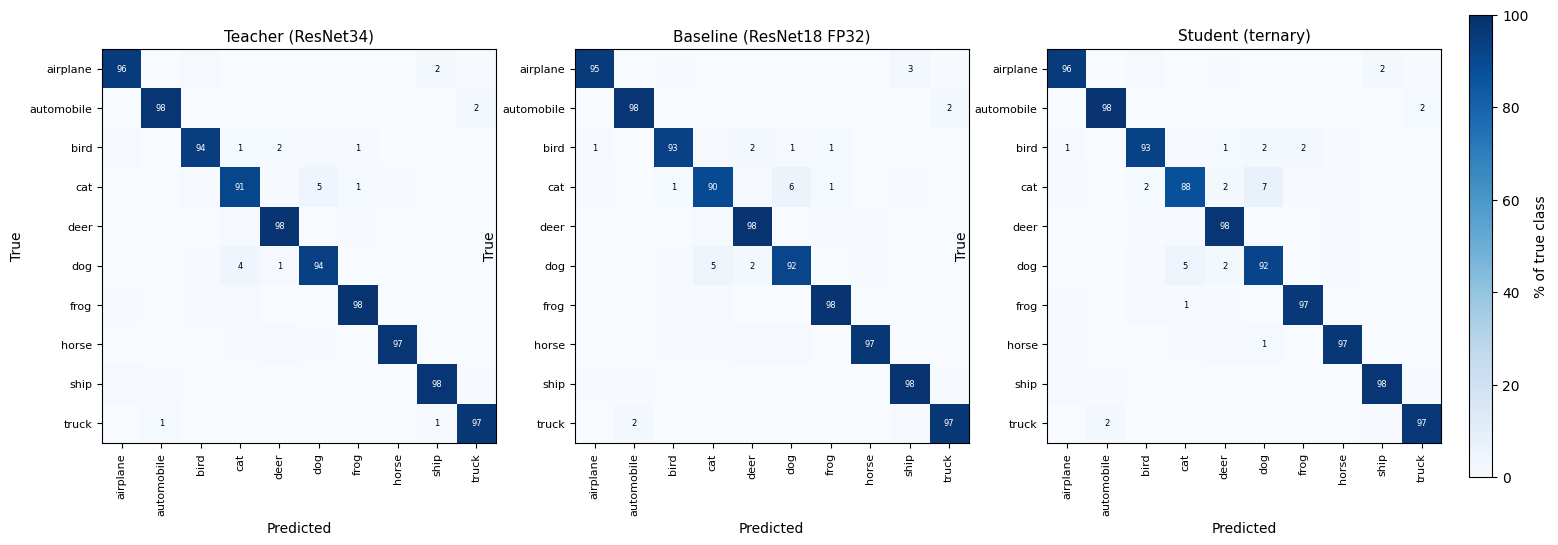

In [ ]:
def compute_confusion_matrix(model, loader, num_classes=10):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            preds = model(x).argmax(1).cpu()
            for t, p in zip(y, preds):
                cm[t, p] += 1
    return cm.numpy()

confusion_matrices = {name: compute_confusion_matrix(m, test_loader) for name, m in models.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(10)); ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(name, fontsize=11)
    for i in range(10):
        for j in range(10):
            val = cm_pct[i, j]
            if val > 1:  # skip near-zero cells to reduce clutter
                ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                         color="white" if val > 50 else "black", fontsize=6)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="% of true class")
plt.savefig(os.path.join(DRIVE_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Per-class accuracy comparison

The diagonal of each confusion matrix above, plotted side by side per class -- this is usually more useful than the 3x10x10 grid for actually spotting *which specific classes* the student loses the most accuracy on relative to the teacher.

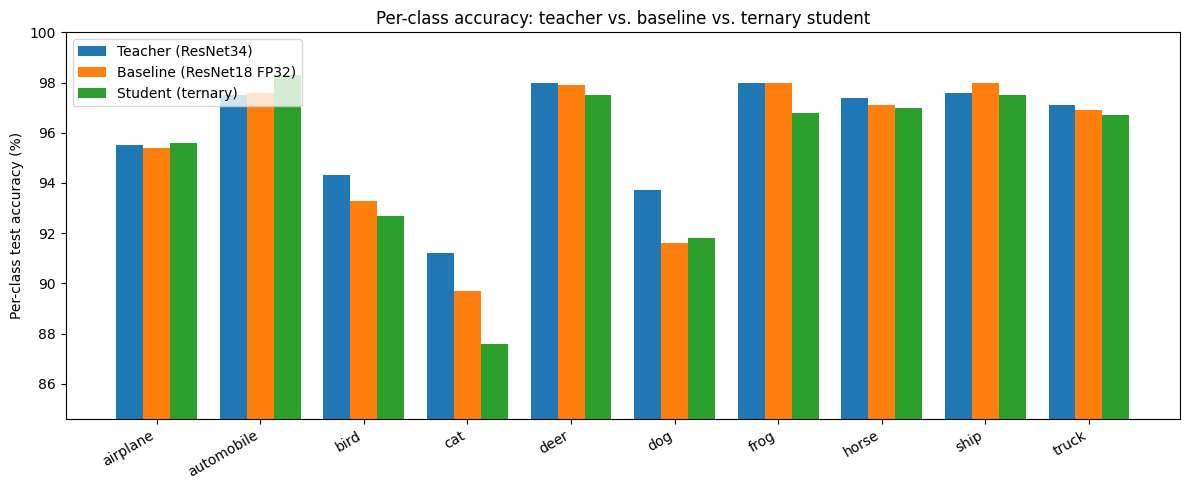

Classes ranked by (teacher acc - student acc), largest gap first:
  cat           teacher 91.2%  student 87.6%  gap +3.6 pts
  dog           teacher 93.7%  student 91.8%  gap +1.9 pts
  bird          teacher 94.3%  student 92.7%  gap +1.6 pts
  frog          teacher 98.0%  student 96.8%  gap +1.2 pts
  deer          teacher 98.0%  student 97.5%  gap +0.5 pts
  horse         teacher 97.4%  student 97.0%  gap +0.4 pts
  truck         teacher 97.1%  student 96.7%  gap +0.4 pts
  ship          teacher 97.6%  student 97.5%  gap +0.1 pts
  airplane      teacher 95.5%  student 95.6%  gap -0.1 pts
  automobile    teacher 97.5%  student 98.3%  gap -0.8 pts


In [ ]:
per_class_acc = {name: np.diag(cm) / cm.sum(axis=1) * 100 for name, cm in confusion_matrices.items()}

x = np.arange(10)
width = 0.26
fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, accs) in enumerate(per_class_acc.items()):
    ax.bar(x + (i - 1) * width, accs, width, label=name)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_ylabel("Per-class test accuracy (%)")
ax.set_ylim(min(min(v) for v in per_class_acc.values()) - 3, 100)
ax.set_title("Per-class accuracy: teacher vs. baseline vs. ternary student")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "per_class_accuracy.png"), dpi=150)
plt.show()

# Print the classes where the student loses the most accuracy relative to the teacher
teacher_acc = per_class_acc["Teacher (ResNet34)"]
student_acc = per_class_acc["Student (ternary)"]
gap = teacher_acc - student_acc
order = np.argsort(-gap)
print("Classes ranked by (teacher acc - student acc), largest gap first:")
for idx in order:
    print(f"  {CLASS_NAMES[idx]:12s}  teacher {teacher_acc[idx]:.1f}%  student {student_acc[idx]:.1f}%  gap {gap[idx]:+.1f} pts")

## 3. Where do parameters live in the architecture?

Groups every parameter by which part of the network it belongs to (stem, each of the four residual stages, or the final FC layer) and compares that profile across all three models. This is useful for your architecture discussion -- it shows visually that most parameters live in the later, wider stages (layer3/layer4), which is exactly where ternarization saves the most space.

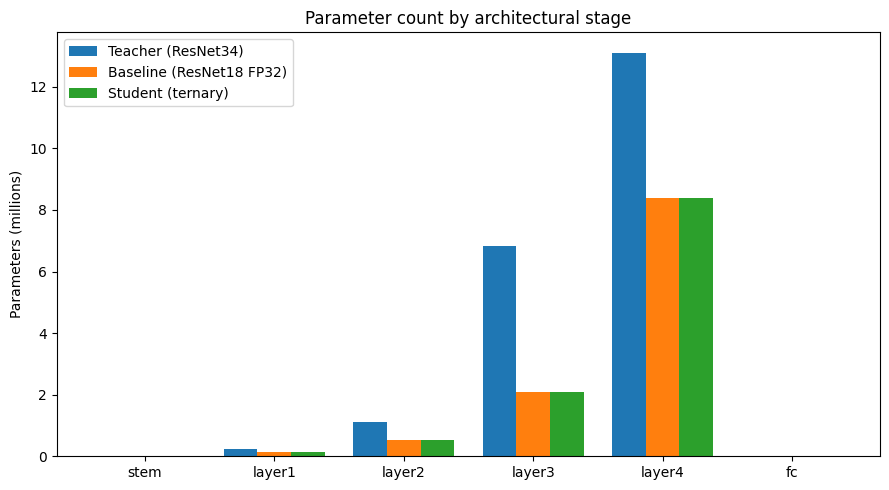

In [ ]:
def params_by_stage(model):
    groups = {"stem": 0, "layer1": 0, "layer2": 0, "layer3": 0, "layer4": 0, "fc": 0}
    for name, p in model.named_parameters():
        top = name.split(".")[0]
        if top in ("conv1", "bn1"):
            groups["stem"] += p.numel()
        elif top in groups:
            groups[top] += p.numel()
    return groups

stage_data = {name: params_by_stage(m) for name, m in models.items()}
stages = list(next(iter(stage_data.values())).keys())
x = np.arange(len(stages))
width = 0.26

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, groups) in enumerate(stage_data.items()):
    values_m = [groups[s] / 1e6 for s in stages]
    ax.bar(x + (i - 1) * width, values_m, width, label=name)
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel("Parameters (millions)")
ax.set_title("Parameter count by architectural stage")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "params_by_stage.png"), dpi=150)
plt.show()

## 4. Student model-size budget: where do the bits actually go?

Not parameter *count* (which is identical to the FP32 baseline) but actual *storage bits* -- since ternary weights cost 2 bits each while the retained FP32 layers and the per-channel alpha overhead still cost 32 bits each, the compression story is really about bits, not parameter counts.

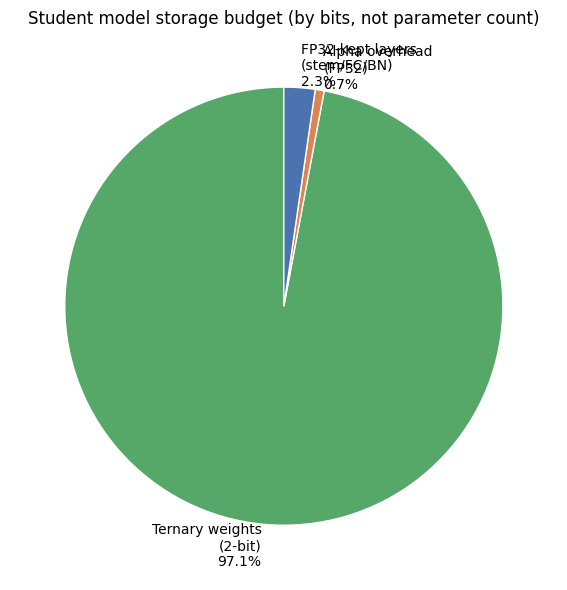

Ternary weight bits: 22,315,008 (97.05%)
Alpha overhead bits: 151,552 (0.66%)
FP32-kept bits:      526,656 (2.29%)


In [ ]:
ternary_weight_params, alpha_overhead_params = 0, 0
for module in student.modules():
    if isinstance(module, (TernaryConv2d, TernaryLinear)):
        ternary_weight_params += module.weight.numel()
        alpha_overhead_params += module.weight.shape[0] if module.per_channel else 1

total_params = sum(p.numel() for p in student.parameters())
fp32_kept_params = total_params - ternary_weight_params

ternary_bits = ternary_weight_params * 2
alpha_bits = alpha_overhead_params * 32
fp32_bits = fp32_kept_params * 32
total_bits = ternary_bits + alpha_bits + fp32_bits

labels = [f"Ternary weights\n(2-bit)\n{100*ternary_bits/total_bits:.1f}%",
          f"Alpha overhead\n(FP32)\n{100*alpha_bits/total_bits:.1f}%",
          f"FP32-kept layers\n(stem/FC/BN)\n{100*fp32_bits/total_bits:.1f}%"]
sizes = [ternary_bits, alpha_bits, fp32_bits]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=["#55A868", "#DD8452", "#4C72B0"], autopct=lambda p: f"{p:.1f}%" if False else "",
        startangle=90, wedgeprops={"edgecolor": "white"})
plt.title("Student model storage budget (by bits, not parameter count)")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "size_breakdown_pie.png"), dpi=150)
plt.show()

print(f"Ternary weight bits: {ternary_bits:,} ({100*ternary_bits/total_bits:.2f}%)")
print(f"Alpha overhead bits: {alpha_bits:,} ({100*alpha_bits/total_bits:.2f}%)")
print(f"FP32-kept bits:      {fp32_bits:,} ({100*fp32_bits/total_bits:.2f}%)")

## 5. Weight distribution by network depth

A more general version of the single aggregate histogram from before: does the *distribution* of latent weight magnitudes change as you go deeper into the network? Box plots let you compare the four residual stages directly.

/tmp/ipykernel_1949/3264846532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(stage_weights.values(), labels=stage_weights.keys(), showfliers=False)


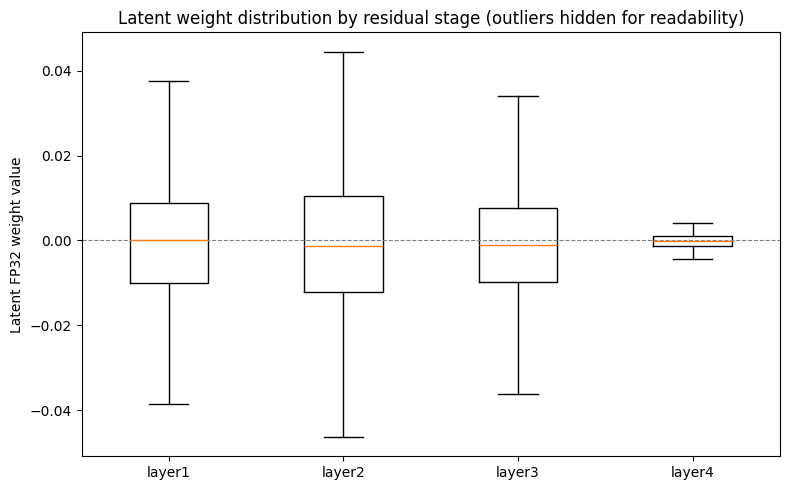

In [ ]:
stage_weights = {"layer1": [], "layer2": [], "layer3": [], "layer4": []}
for name, module in student.named_modules():
    if isinstance(module, (TernaryConv2d, TernaryLinear)):
        top = name.split(".")[0]
        if top in stage_weights:
            stage_weights[top].append(module.weight.detach().flatten().numpy())

stage_weights = {k: np.concatenate(v) for k, v in stage_weights.items() if len(v) > 0}

plt.figure(figsize=(8, 5))
plt.boxplot(stage_weights.values(), labels=stage_weights.keys(), showfliers=False)
plt.ylabel("Latent FP32 weight value")
plt.title("Latent weight distribution by residual stage (outliers hidden for readability)")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "weight_distribution_by_depth.png"), dpi=150)
plt.show()

## 6. Qualitative sample predictions

A grid of actual test images with each model's prediction underneath -- lets a reader *see* a few concrete cases rather than only reading accuracy numbers. Titles are green if that model got the image right, red if wrong.

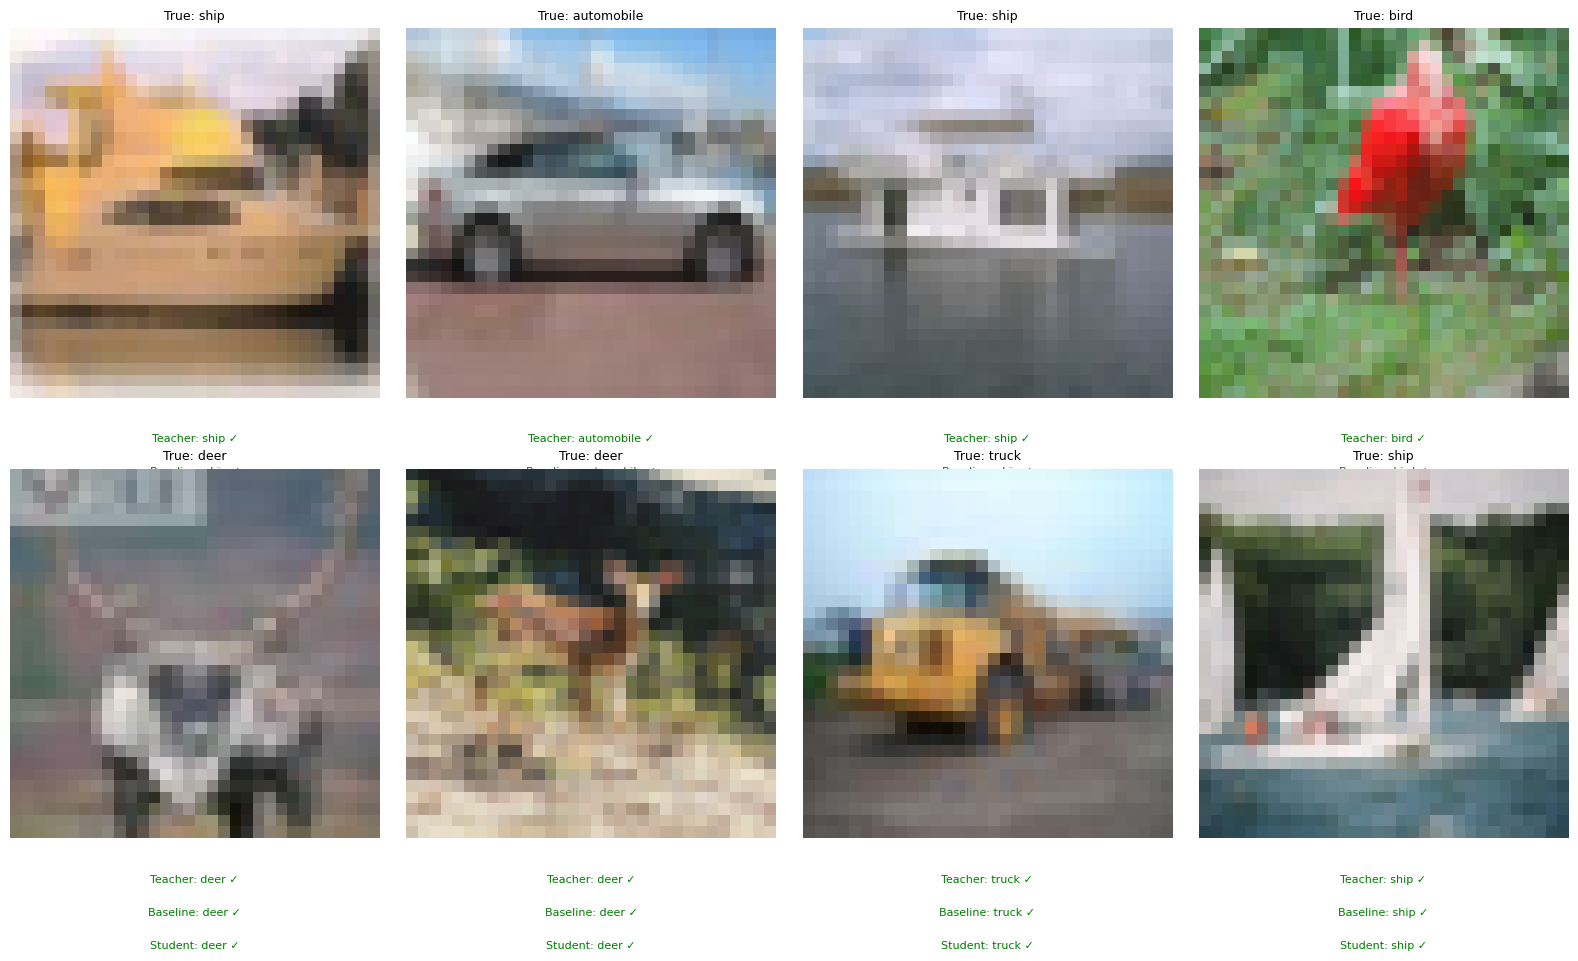

In [ ]:
torch.manual_seed(SEED)
sample_indices = torch.randperm(len(test_set))[:8].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
mean_t = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_STD).view(3, 1, 1)

for ax, idx in zip(axes.flat, sample_indices):
    img_tensor, true_label = test_set[idx]
    img_display = (img_tensor * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

    x_in = img_tensor.unsqueeze(0).to(DEVICE)
    lines = [f"True: {CLASS_NAMES[true_label]}"]
    for name, m in models.items():
        with torch.no_grad():
            pred = m(x_in).argmax(1).item()
        short_name = name.split(" ")[0]
        correct = "correct" if pred == true_label else "wrong"
        lines.append(f"{short_name}: {CLASS_NAMES[pred]} ({correct})")

    ax.imshow(img_display)
    ax.axis("off")
    title_lines = [lines[0]] + [
        (l, "green" if "(correct)" in l else "red") for l in lines[1:]
    ]
    ax.set_title(lines[0], fontsize=9)
    y_pos = -0.12
    for l, color in title_lines[1:]:
        ax.text(0.5, y_pos, l.replace(" (correct)", " ✓").replace(" (wrong)", " ✗"),
                 transform=ax.transAxes, ha="center", fontsize=8, color=color)
        y_pos -= 0.09

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "sample_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()

## Adding these to your LaTeX report

All six PNGs are saved to `atdl/`. Suggested placement in your report:

| Figure | Suggested section |
|---|---|
| `confusion_matrices.png` | New subsection under Task 4, e.g. "6.4 Per-Class Behavior" |
| `per_class_accuracy.png` | Same subsection, right after the confusion matrices |
| `params_by_stage.png` | Task 2 (architecture discussion) or Task 4 (compression analysis) |
| `size_breakdown_pie.png` | Task 4, right next to the compression-ratio equations |
| `weight_distribution_by_depth.png` | Task 2 or the weight-distribution subsection from before |
| `sample_predictions.png` | A short qualitative paragraph near the end of Task 4, before the Discussion section |

Copy them next to your `.tex` file and use the same `\includegraphics` pattern as your existing figures, e.g.:

```latex
\begin{figure}[h]
    \centering
    \includegraphics[width=0.95\textwidth]{confusion_matrices.png}
    \caption{Confusion matrices (row-normalized, \%) for the teacher, FP32 baseline, and ternary student.}
    \label{fig:confusion_matrices}
\end{figure}
```